# Primi passi con scikit-learn 

Introduzione alla Data Science, AA 2025/2026

Docenti: Luca Calatroni, Lorenzo Rosasco

*Obiettivi*
- testare scikit-learn su un dataset reale;
- capire il workflow standard di una pipeline di machine learning;
- collegare le astrazioni di scikit-learn ai modelli già implementati manualmente con NumPy;
- mostrare come sia facile sostituire un modello con un altro;
- introdurre il tema dei dati multi-dimensionali e della loro visualizzazione (cenno alla PCA, senza teoria)

## 1. Installazione

Se `scikit-learn` non è installato nell'ambiente corrente, questa cella prova a installarlo automaticamente.

In [1]:
try:
    import sklearn
    print("scikit-learn già disponibile. Versione:", sklearn.__version__)
except ImportError:
    print("scikit-learn non trovato. Installazione in corso...")
    import sys
    !{sys.executable} -m pip install scikit-learn

scikit-learn già disponibile. Versione: 1.7.2


> **Nota:** se l'installazione avviene davvero, può essere necessario riavviare il kernel prima di continuare.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Import dei datasets e delle funzioni richieste

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


## 2. Caricamento di un dataset reale

Useremo il dataset **Breast Cancer** incluso in scikit-learn.
- è un dataset **reale**;
- è un problema di **classificazione binaria**;
- ha **molte feature**, quindi ci permette di andare oltre il caso monodimensionale visto finora.


In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Shape di X:", X.shape)
print("Shape di y:", y.shape)

Shape di X: (569, 30)
Shape di y: (569,)


- Quanti campioni ci sono?
- Quante feature ha ogni campione?
- Quante etichette?

In [4]:
# X: (n_samples, n_features)
# y: (n_samples,)

print("Numero di campioni:", X.shape[0])
print("Numero di feature:", X.shape[1])
print("Numero di labels:", y.shape[0])

Numero di campioni: 569
Numero di feature: 30
Numero di labels: 569


In [5]:
# Osserviamo un campione e le sue features

print("Primo campione (feature):\n", X[0])
print("Label:", y[0])


Primo campione (feature):
 [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
Label: 0


Notare che rispetto a quanto visto in classe le etichette sono codificate come `0` e `1`.

In [6]:
print("Valori possibili delle label:", np.unique(y))
print("Nomi delle classi:", data.target_names)


Valori possibili delle label: [0 1]
Nomi delle classi: ['malignant' 'benign']


In [7]:
print("Nomi delle feature:", data.feature_names)

Nomi delle feature: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


## 3. Suddivisione in train e test

> Come mai necessitiamo di dividere in train/test set?
- il **training set** serve per imparare i parametri del modello;
- il **test set** serve per simulare dati mai visti prima.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # fissiamo proporzione train/test e seed (fissato per motivi di reproducibility)
)

print("Shape training set:", X_train.shape)  # Quale dimensione cambia?
print("Shape test set:", X_test.shape)


Shape training set: (455, 30)
Shape test set: (114, 30)


## 4. Classificazione con modello lineare e Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression


Come abbiamo visto, minimizzare il rischio empirico con regressione logistica richiede la minimizzazione non esplicita di una funziona che viene fatta con metodi iterativi, come la discesa del gradiente. Usiamo `max_iter=5000` per rendere più semplice la convergenza ed evitare warning inutili durante la lezione.


In [10]:
model = LogisticRegression(max_iter=5000)   # pre-carichiamo il modello


Se metto meno iterazioni non converge

## 5. Sulla linearità del modello nel caso multivariato

Quando scegliamo:

```python
LogisticRegression()
```

stiamo già scegliendo **uno specifico spazio di ipotesi**: un modello **lineare nelle feature**.

### Struttura del modello
Per $x \in \mathbb{R}^d$ il modello lineare ora è:

$$
f(x) = w^\top x + b
$$

dove:
- $w \in \mathbb{R}^d$ è il vettore dei **pesi**;
- $b \in \mathbb{R}$ è il **bias** (o intercetta).

Nel caso 1D, $x\in\R$ avevamo semplicemente preso come modello $f(x)=wx$, $w\in\mathbb{R}$.


## 6. Non-linearità? 

Un esempio molto semplice visto in classe di non linearità è il *segno*, che resituisce valori $-1$ e $+1$. 
Una non-linearità standard è la **sigmoide** (può essere pensata come approssimazione liscia ma non lineare del segno)

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

e il modello dunque è

$$
\hat{f}(x) = \sigma(f(x)) = \sigma(w^\top x + b)
$$

### Osservazione importante
- la parte $w^\top x + b$ è **lineare**;
- la funzione sigmoide rende l'output interpretabile come probabilità: le quantità sono ora in $[0,1]$;
- il **confine di decisione** resta comunque lineare, perché dipende dal segno o dalla soglia applicata a $w^\top x + b$.


## 7. Regolarizzazione

Di default, per etichette binarie, la loss che viene minimizzata è:

$$
\min_{w,b} \frac{1}{n} \sum_{i=1}^n \ell\big(y_i, w^\top x_i + b\big) + \lambda \|w\|^2
$$

dove:
- $\ell$ è la **loss logistica**;
- $\lambda \|w\|^2$ è il termine di **regolarizzazione L2**.
Questo significa che il problema ottimizzato non è solo "adattarsi bene ai dati", ma anche "mantenere i pesi ragionevolmente piccoli".
In pratica serve solo a controllare la complessità del modello.
- $\lambda$ bilancia l'effetto della loss e della regolarizzazione. E' un iperparametro.

## 8. Utilizzo della funzione`fit()`

- il modello legge i dati di training;
- cerca valori buoni per $w$ e $b$;
- minimizza la loss sui dati di training (sklearn utilizza metodi come GD ma più sofisticati);
- usa metodi numerici ottimizzati.

In [11]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


Una volta che il modello è stato addestrato, possiamo chiedergli di predire le etichette su dati di test.


In [12]:
y_pred = model.predict(X_test)
print("Prime 10 predizioni:", y_pred[:10])

Prime 10 predizioni: [1 0 0 1 1 0 0 0 1 1]


### Confronto con le etichette vere

Per ora osserviamo soltanto il risultato, senza introdurre ancora metriche di valutazione formali.


In [13]:
print("Predizioni:", y_pred[:10])
print("Etichette vere:", y_test[:10])

Predizioni: [1 0 0 1 1 0 0 0 1 1]
Etichette vere: [1 0 0 1 1 0 0 0 1 1]


Guardiamo direttamente i parametri imparati.


In [14]:
print("Shape di model.coef_:", model.coef_.shape)
print("Bias (intercept_):", model.intercept_)


Shape di model.coef_: (1, 30)
Bias (intercept_): [29.28148831]


In [15]:
print("Prime 10 componenti del vettore dei pesi:")
print(model.coef_[0][:10])


Prime 10 componenti del vettore dei pesi:
[ 1.00323648  0.22525063 -0.3700116   0.02624281 -0.15142407 -0.23622646
 -0.51912066 -0.27099518 -0.22287615 -0.03689926]


## 8. Il pattern generale di scikit-learn

1. scegliere un modello;
2. creare l'oggetto del modello;
3. eseguire `fit(X_train, y_train)`;
4. eseguire `predict(X_test)`.

In [16]:
# Workflow generale in scikit-learn:
#
# 1. model = SomeModel(...)
# 2. model.fit(X_train, y_train)
# 3. y_pred = model.predict(X_test)


In [17]:
# Possiamo dunque cambiare modello semplicemente importando quello che ci interessa

from sklearn.neighbors import KNeighborsClassifier

Per default, `KNeighborsClassifier()` usa `n_neighbors=5`.


In [18]:
knn = KNeighborsClassifier(n_neighbors=5)

### Cosa fa `fit()` in KNN?

Qui `fit()` non significa "ottimizzare dei pesi" come prima.  
Significa piuttosto memorizzare la struttura dei dati di training in modo da poter poi cercare i vicini durante la predizione.


In [19]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predizioni con KNN


In [20]:
y_pred_knn = knn.predict(X_test)
print("Prime 10 predizioni KNN:", y_pred_knn[:10])


Prime 10 predizioni KNN: [1 0 0 1 1 0 0 0 1 1]


/private/var/containers/Bundle/Application/A29D584C-BD55-4E92-A47C-7016BD0F7BE4/Carnets-sci.app/Library/lib/python3.13/site-packages/threadpoolctl.py:990: RuntimeWarning: Could not find dl_iterate_phdr in the C standard library.
  warnings.warn(


## 16. Confronto tra i due modelli

Osserviamo che modelli diversi possono produrre predizioni diverse.


In [21]:
print("Logistic Regression:", y_pred[:20])
print("KNN               :", y_pred_knn[:20])

Logistic Regression: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]
KNN               : [1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0]


In [22]:
# Controlliamo se le predizioni coincidono nonostante la differenza di modelli utilizzati

diff = np.sum(y_pred != y_pred_knn)
print("Numero di predizioni diverse:", diff)

Numero di predizioni diverse: 4


- Perché due modelli diversi possono dare risposte diverse?
- Questo significa automaticamente che uno dei due è peggiore?

## 9. Parametri e iperparametri

In scikit-learn è utile distinguere:

- **parametri del modello**: quelli appresi dai dati (`coef_`, `intercept_`);
- **iperparametri**: quelli scelti dall'utente prima del training per far 'girare' il training'.

Esempi:
- `max_iter` nella Logistic Regression;
- `n_neighbors` in KNN.


In [23]:
# Per ogni modello 'get_params' mostra gli iperaparametri

print("Parametri di Logistic Regression:")
print(model.get_params())

print("\nParametri di KNN:")
print(knn.get_params())


Parametri di Logistic Regression:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 5000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Parametri di KNN:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [24]:
# Proviamo a cambiare il numero di vicini considerati in kNN ---> con n=1 diventa NN

knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_train, y_train)
y_pred_knn_1 = knn_1.predict(X_test)

print("Prime 20 predizioni con KNN (1 vicino):", y_pred_knn_1[:20])


Prime 20 predizioni con KNN (1 vicino): [1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0]


Punto importante: il nostro dataset ha molte feature, quindi **non possiamo visualizzarlo direttamente** in uno spazio 30-dimensionale.
I modelli lavorano naturalmente in dimensione alta, ma noi possiamo mostrare solo:
- proiezioni su poche feature --> *perdita di informazioni*;
- riduzioni di dimensionalità: "comprimere" tutte le features in uno spazio low-dimensional


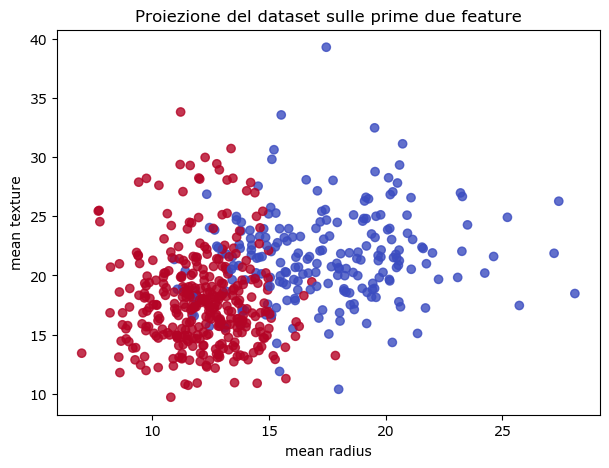

In [25]:
# Scegliamo due features e mostriamo i label in questo sottospazio

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.8)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Proiezione del dataset sulle prime due feature")
plt.show()


### 10 Opzionale: riduzione di dimensionalità con PCA

Una strategia più informativa consiste nel proiettare i dati su due direzioni significative usando Principal Component Analysis (PCA), una tecnica che cerca nuove direzioni nello spazio delle feature che catturino molta variabilità dei dati.  
Non è una tecnica di classificazione: è una tecnica di **rappresentazione** e **compressione**.

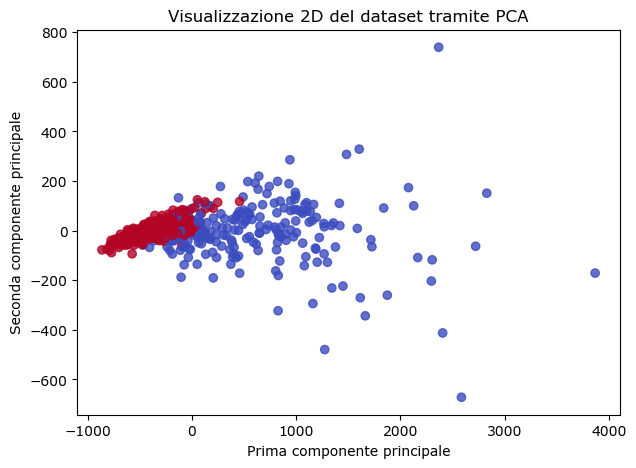

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.8)
plt.xlabel("Prima componente principale")
plt.ylabel("Seconda componente principale")
plt.title("Visualizzazione 2D del dataset tramite PCA")
plt.show()
